In [1]:
import sys
from pathlib import Path

notebook_dir = Path().resolve()
project_root = notebook_dir.parent
sys.path.insert(0, str(project_root))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from matplotlib.colors import to_rgba

from chow_liu import ChowLiuTree, MutualInfo
from bootstrap import NetworkBootstrap, chow_liu_edge_fn
from resources.schemas.config_experiment import *

DATA_PATH = "../data/grinding_normalized.csv"
RANDOM_STATE = 42

## Data reading

In [3]:
df_model = pd.read_csv(DATA_PATH)
df_model.head()

,ids,doi,Type of Synthesis,Formula,API,Coformer,Part of Ratio API,Part of Ratio Coformer,Amount of API,Amount of Coformer,...,Frequency Unit,Mixing Time,Mixing Time Unit,Mixing Temperature,Mixing Temperature Unit,Drying Time,Drying Time Unit,Drying Temperature,Drying Temperature Unit,Temperature of Drying (numeric)
0,id0007,10.3390/pharmaceutics13040546,liquid-assisted grinding,MTZ-EG,metronidazole,ethyl gallate,"[0.5, 1.5)","[0.5, 1.5)","[21.2, 33.3)","[21.1, 33.8)",...,hz,"[30.0, 40.0)",min,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED
1,id0008,10.1007/s10870-011-0147-y,liquid-assisted grinding,CBZ-HQ,carbamazepine,hydroquinone,"[0.5, 1.5)","[0.5, 1.5)",NOT_DETECTED,NOT_DETECTED,...,hz,"[15.0, 20.0)",min,"[30.0, inf)",c,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED
2,id0008,10.1007/s10870-011-0147-y,liquid-assisted grinding,CBZ-HQ,carbamazepine,hydroquinone,"[0.5, 1.5)","[1.5, 2.5)",NOT_DETECTED,NOT_DETECTED,...,hz,"[15.0, 20.0)",min,"[30.0, inf)",c,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED
3,id0008,10.1007/s10870-011-0147-y,liquid-assisted grinding,CBZ-HQ,carbamazepine,hydroquinone,"[1.5, 2.5)","[0.5, 1.5)",NOT_DETECTED,NOT_DETECTED,...,hz,"[15.0, 20.0)",min,"[30.0, inf)",c,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED
4,id0008,10.1007/s10870-011-0147-y,liquid-assisted grinding,PA-HQ,piracetam,hydroquinone,"[0.5, 1.5)","[0.5, 1.5)",NOT_DETECTED,NOT_DETECTED,...,hz,"[15.0, 20.0)",min,"[30.0, inf)",c,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED


In [129]:
def plot_tree(graph, node_color="darkseagreen", random_state_addition=989, title=''):
    fig, ax = plt.subplots(figsize=(11, 8))
    pos = nx.spring_layout(graph, seed=RANDOM_STATE+random_state_addition, k=5000, method="energy", scale=30)
    weights = [graph[u][v]["weight"] for u, v in graph.edges()]

    nx.draw_networkx_nodes(graph, pos, node_color=node_color, node_size=2000, ax=ax)
    nx.draw_networkx_labels(graph, pos, font_size=8, ax=ax)
    nx.draw_networkx_edges(graph, pos, width=[1 + 10 * w for w in weights], ax=ax, alpha=0.7)
    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


def plot_mi_matrix(mi_result):
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(mi_result.info_matrix.astype(float), cmap="viridis", ax=ax,
                cbar_kws={"label": "mutual information"})
    ax.set_title("Pairwise mutual information")
    plt.tight_layout()
    plt.show()

## Mutual Info

In [13]:
MIN_PAIRS = 5
mi_result_rel = MutualInfo(min_pairs=MIN_PAIRS).compute(df_model, columns=RELEVANT_COLUMNS)
mi_result_all = MutualInfo(min_pairs=MIN_PAIRS).compute(df_model, columns=VARIABLE_COLUMNS)

mi_result_all.top_pairs(15)

,V1,V2,mutual_info,n_pairs
0,Amount of API,Amount of Coformer,0.792818,1376
1,Mixing Apparatus,Mixing Frequency,0.500429,1584
2,Type of Synthesis,Solvent,0.442558,2559
3,Part of Ratio API,Part of Ratio Coformer,0.329337,3629
4,Mixing Apparatus,Mixing Time,0.280417,2673
5,Solvent,Amount of Solvent,0.267462,1364
6,Mixing Frequency,Mixing Time,0.217340,1493
7,Amount of Solvent,Mixing Frequency,0.188856,886
8,Amount of Solvent,Mixing Time,0.182559,1295
9,Mixing Apparatus,Amount of Solvent,0.162663,1289


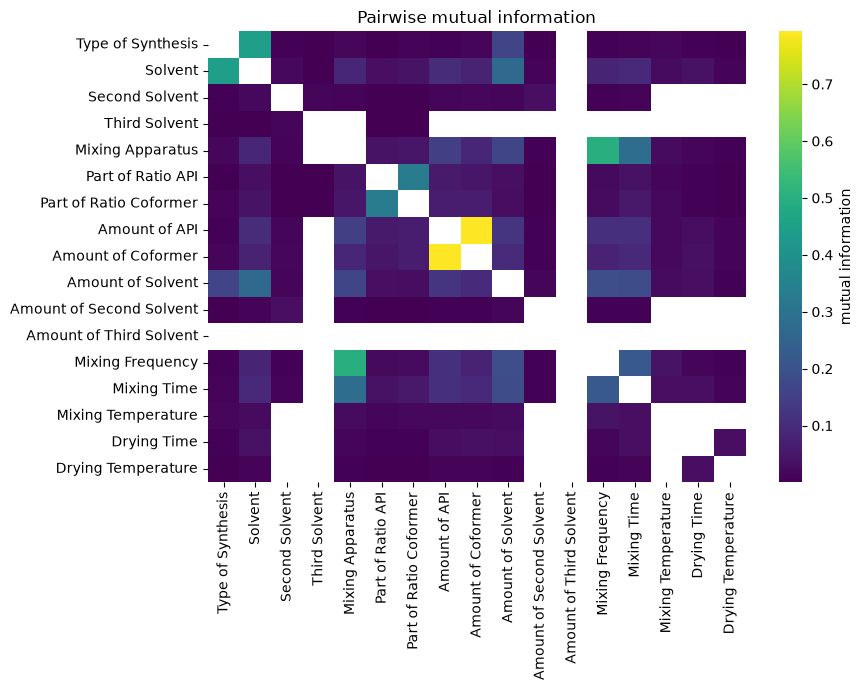

In [15]:
plot_mi_matrix(mi_result_all)

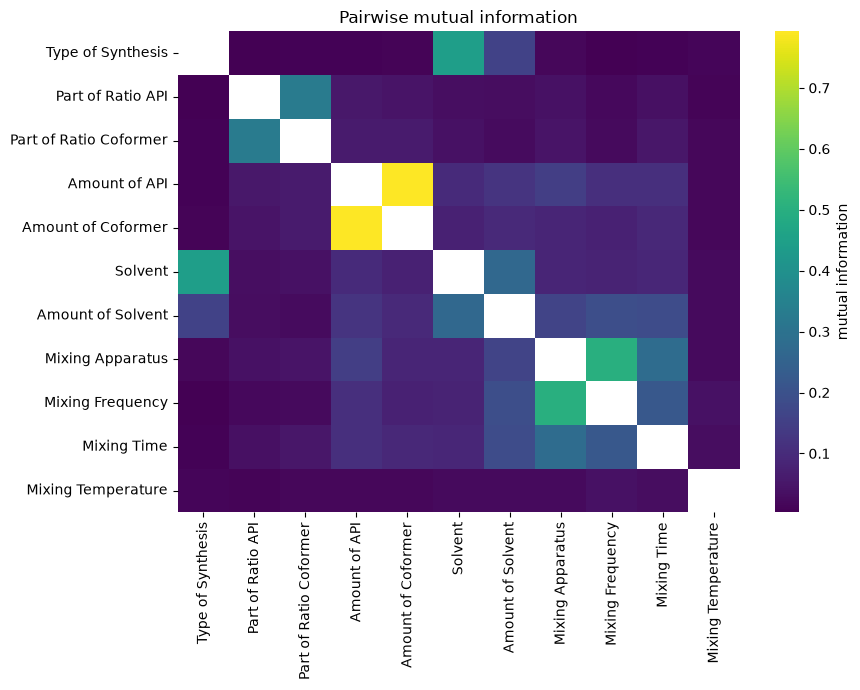

In [14]:
plot_mi_matrix(mi_result_rel)

## Chow-Liu trees

In [16]:
tree_all = ChowLiuTree().fit(mi_result_all.info_matrix)
tree_all.edge_table()

,V1,V2,mutual_info
0,Amount of API,Amount of Coformer,0.792818
1,Mixing Apparatus,Mixing Frequency,0.500429
2,Type of Synthesis,Solvent,0.442558
3,Part of Ratio API,Part of Ratio Coformer,0.329337
4,Mixing Apparatus,Mixing Time,0.280417
5,Solvent,Amount of Solvent,0.267462
6,Amount of Solvent,Mixing Frequency,0.188856
7,Mixing Apparatus,Amount of API,0.146812
8,Part of Ratio Coformer,Amount of API,0.061281
9,Mixing Frequency,Mixing Temperature,0.039114


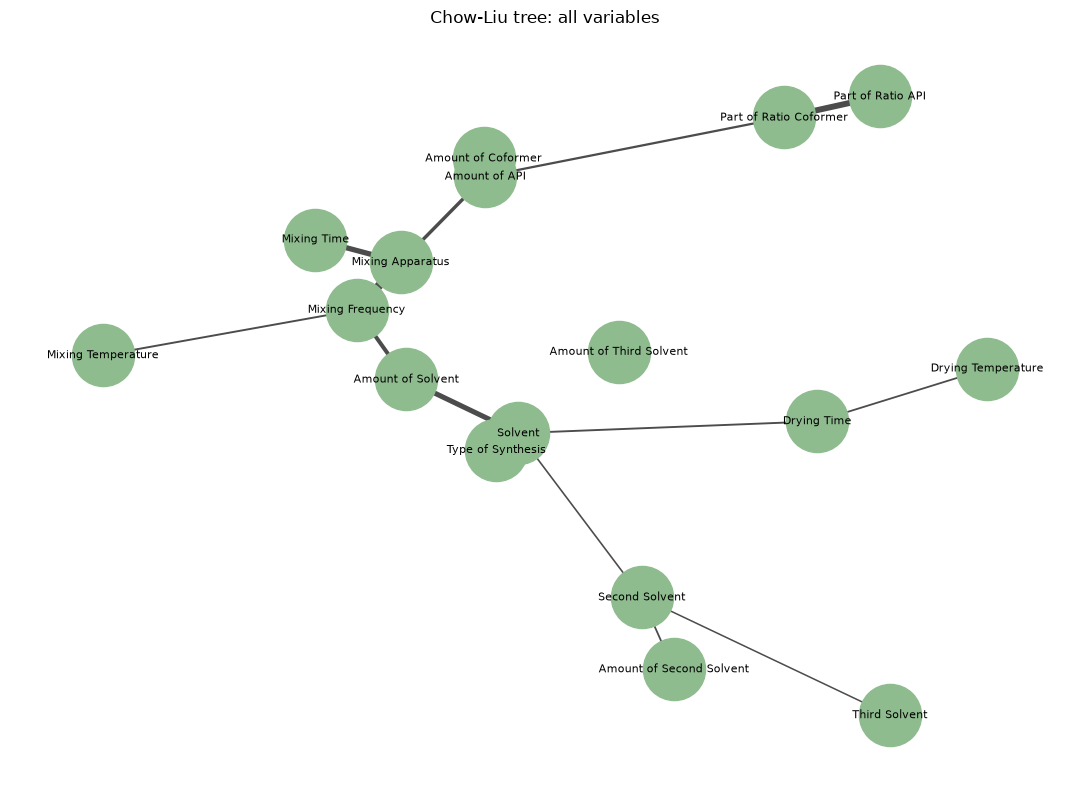

In [167]:
plot_tree(tree_all.graph, node_color="darkseagreen", title="Chow-Liu tree: all variables", random_state_addition=5041)

In [84]:
tree_rel = ChowLiuTree().fit(mi_result_rel.info_matrix)
tree_rel.edge_table()

,V1,V2,mutual_info
0,Amount of API,Amount of Coformer,0.792818
1,Mixing Apparatus,Mixing Frequency,0.500429
2,Type of Synthesis,Solvent,0.442558
3,Part of Ratio API,Part of Ratio Coformer,0.329337
4,Mixing Apparatus,Mixing Time,0.280417
5,Solvent,Amount of Solvent,0.267462
6,Amount of Solvent,Mixing Frequency,0.188856
7,Amount of API,Mixing Apparatus,0.146812
8,Part of Ratio Coformer,Amount of API,0.061281
9,Mixing Frequency,Mixing Temperature,0.039114


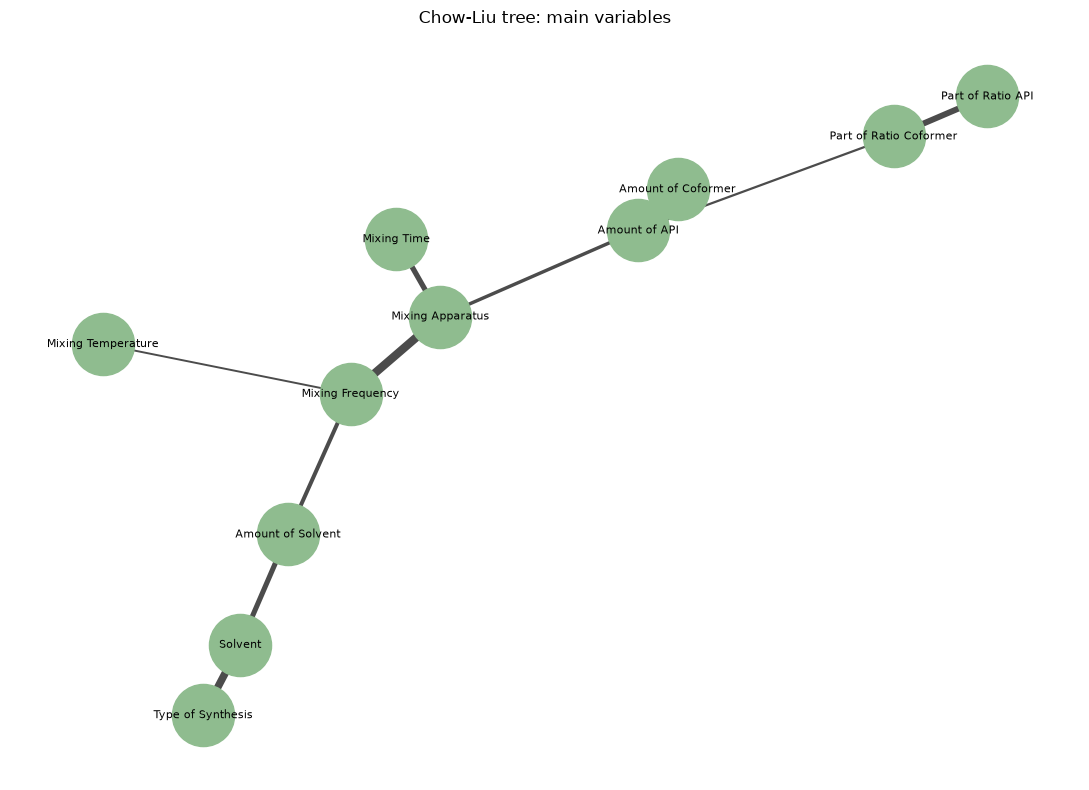

In [151]:
plot_tree(tree_rel.graph, node_color="darkseagreen", title="Chow-Liu tree: main variables", random_state_addition=91199)

## Bootstrap

In [94]:
N_ITERATIONS_CHOW = 100

chow_fit_fn = chow_liu_edge_fn(columns=VARIABLE_COLUMNS, min_pairs=MIN_PAIRS)
chow_edges_table = NetworkBootstrap(chow_fit_fn, n_iterations=N_ITERATIONS_CHOW).run(df_model)

100%|██████████| 100/100 [04:12<00:00,  2.52s/it]


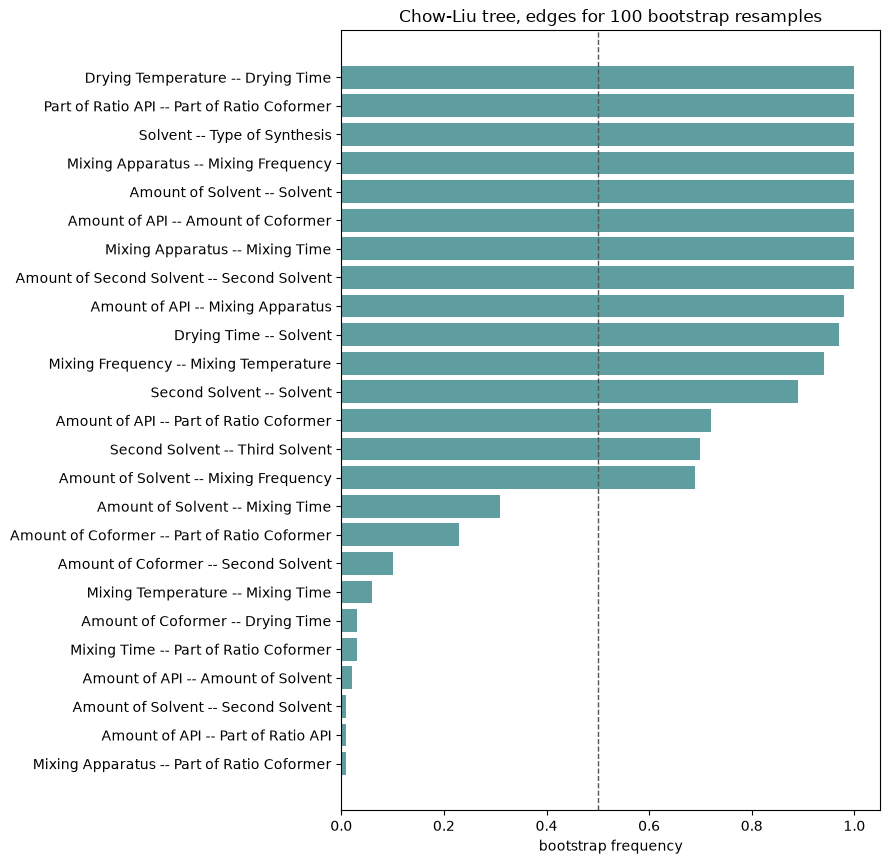

In [97]:
fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(chow_edges_table))))
labels = chow_edges_table["V1"] + " -- " + chow_edges_table["V2"]

ax.barh(labels, chow_edges_table["frequency"], color="cadetblue")
ax.invert_yaxis()
ax.set_xlabel("bootstrap frequency")
ax.set_title(f"Chow-Liu tree, edges for {N_ITERATIONS_CHOW} bootstrap resamples")
ax.axvline(0.5, color="#555", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

In [98]:
def plot_bootstrap_graph(edges_table, node_color="darkseagreen", edge_color="#264653",
                          min_frequency=0.0, random_state_addition=989, title=""):
    graph = nx.Graph()
    for _, row in edges_table.iterrows():
        if row["frequency"] >= min_frequency:
            graph.add_edge(row["V1"], row["V2"], weight=row["frequency"])

    fig, ax = plt.subplots(figsize=(11, 9))
    pos = nx.spring_layout(graph, seed=RANDOM_STATE + random_state_addition, k=50000, weight="weight", method="energy")

    weights = [graph[u][v]["weight"] for u, v in graph.edges()]
    widths = [1 + 6 * w for w in weights]
    colors = [to_rgba(edge_color, alpha=0.15 + 0.8 * w) for w in weights]

    nx.draw_networkx_nodes(graph, pos, node_color=node_color, node_size=2000, ax=ax)
    nx.draw_networkx_labels(graph, pos, font_size=8, ax=ax)
    nx.draw_networkx_edges(graph, pos, ax=ax, width=widths, edge_color=colors)
    ax.set_title(title)
    ax.axis("off")

    plt.tight_layout()
    plt.show()

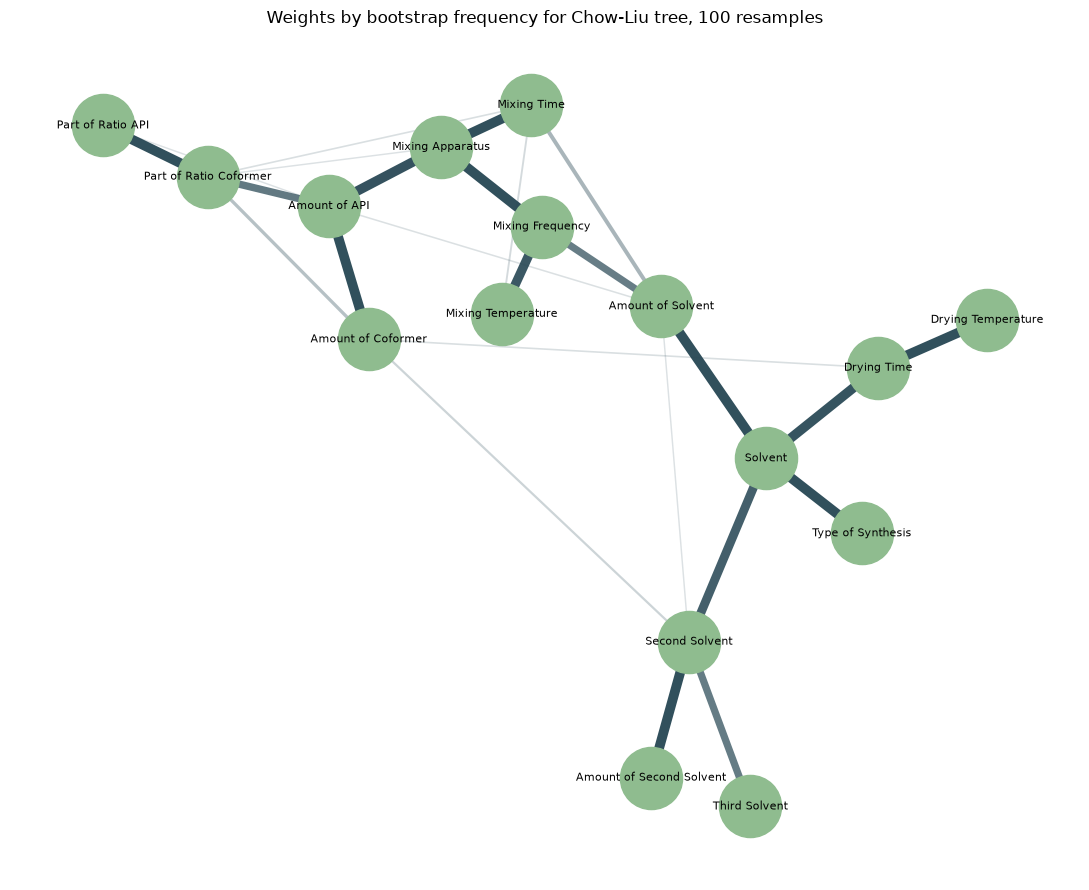

In [168]:
plot_bootstrap_graph(
    chow_edges_table, random_state_addition=2111111221,
    title=f"Weights by bootstrap frequency for Chow-Liu tree, {N_ITERATIONS_CHOW} resamples",
)